# Exploratory Data Analysis

## Preliminaries

In [1]:
# Load libraries
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Load data
train = pd.read_csv('../data/raw/train.csv', sep='|')
items = pd.read_csv('../data/raw/items.csv', sep='|')

df = train.merge(items, 
                   on='pid', 
                   how='left',
                   validate="m:1")

## Initial Data Analysis

In [135]:
pd.set_option('display.max_columns', None)
print(df.head())

   lineID  day    pid  adFlag  availability  competitorPrice  click  basket  \
0       1    1   6570       0             2            14.60      1       0   
1       2    1  14922       1             1             8.57      0       1   
2       3    1  16382       0             1            14.77      0       1   
3       4    1   1145       1             1             6.59      0       0   
4       5    1   3394       0             1             4.39      0       0   

   order  price  revenue  manufacturer     group content unit pharmForm  \
0      0  16.89     0.00           255      2FOI      50   ML       TRO   
1      0   8.75     0.00            18  1COJ0FIK      50   ST       TAB   
2      0  16.06     0.00            41     22OI7    2X50   ML       STI   
3      1   6.55     6.55            52  18OZ00IS      60    G       GEL   
4      1   4.14     4.14            90     20OI0    25X2   ST       KOM   

   genericProduct  salesIndex  category campaignIndex    rrp  
0          

In [168]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 2756003 entries, 0 to 2756002
Data columns (total 21 columns):
 #   Column           Dtype  
---  ------           -----  
 0   lineID           int64  
 1   day              int64  
 2   pid              int64  
 3   adFlag           int64  
 4   availability     int64  
 5   competitorPrice  float64
 6   click            int64  
 7   basket           int64  
 8   order            int64  
 9   price            float64
 10  revenue          float64
 11  manufacturer     int64  
 12  group            str    
 13  content          str    
 14  unit             str    
 15  pharmForm        str    
 16  genericProduct   int64  
 17  salesIndex       int64  
 18  category         float64
 19  campaignIndex    str    
 20  rrp              float64
dtypes: float64(5), int64(11), str(5)
memory usage: 441.6 MB
None


In [138]:
print(df.isnull().sum())

lineID                   0
day                      0
pid                      0
adFlag                   0
availability             0
competitorPrice     100687
click                    0
basket                   0
order                    0
price                    0
revenue                  0
manufacturer             0
group                    0
content                  0
unit                     0
pharmForm           194124
genericProduct           0
salesIndex               0
category             87394
campaignIndex      2287968
rrp                      0
dtype: int64


In [140]:
print(df.duplicated().sum())

0


In [142]:
print(df.nunique())

lineID             2756003
day                     92
pid                  21928
adFlag                   2
availability             4
competitorPrice       4992
click                    2
basket                   2
order                    2
price                 7475
revenue               7520
manufacturer          1065
group                  533
content                548
unit                     8
pharmForm              278
genericProduct           2
salesIndex               4
category               409
campaignIndex            3
rrp                   3282
dtype: int64


                   lineID       day       pid    adFlag  availability  \
lineID           1.000000  0.997790  0.001692 -0.023196      0.017553   
day              0.997790  1.000000  0.002313 -0.024418      0.019050   
pid              0.001692  0.002313  1.000000 -0.123018      0.006680   
adFlag          -0.023196 -0.024418 -0.123018  1.000000     -0.173211   
availability     0.017553  0.019050  0.006680 -0.173211      1.000000   
competitorPrice  0.022622  0.023958  0.096790  0.009946      0.036423   
click            0.108867  0.116116  0.086887 -0.179366      0.119770   
basket          -0.059316 -0.063016 -0.072414  0.115209     -0.054229   
order           -0.072321 -0.077351 -0.036142  0.104110     -0.089054   
price            0.021408  0.022835  0.109019  0.023665      0.051254   
revenue         -0.038033 -0.040944  0.019133  0.072515     -0.048652   
manufacturer     0.018571  0.019701  0.149825 -0.125159      0.091998   
genericProduct  -0.021934 -0.023436 -0.159052  0.12

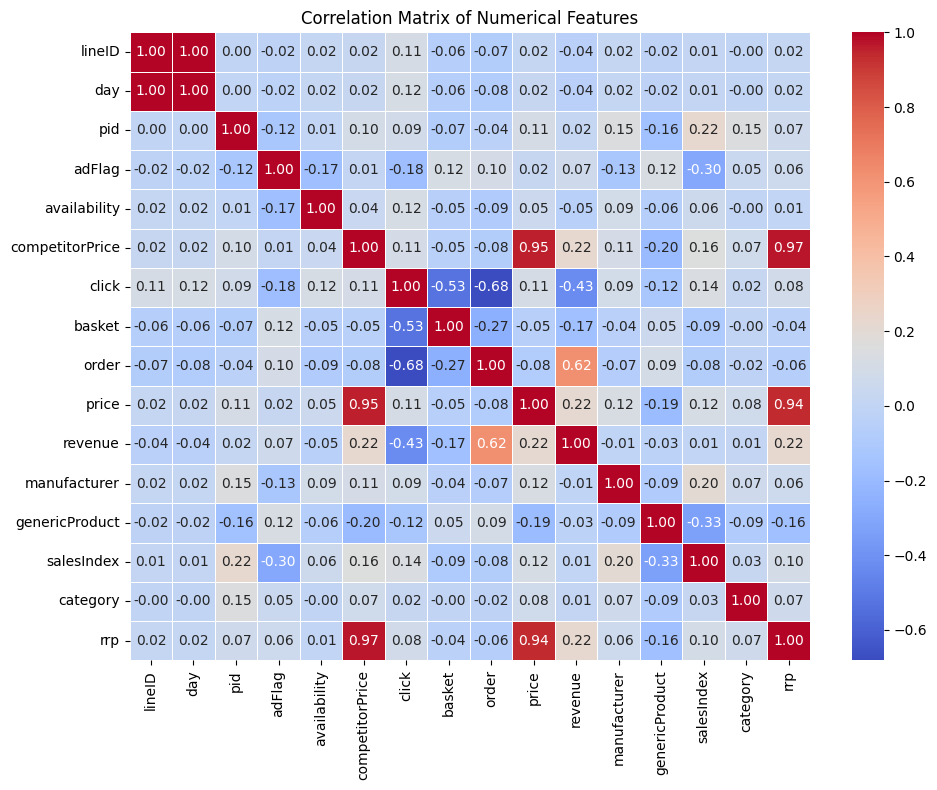

In [3]:
# Numbers
print(df.corr(numeric_only=True))
df.corr(numeric_only=True).to_csv('../reports/correlation_matrix.csv')

# Visualization of correlation matrix
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.savefig('../reports/figures/correlation_matrix.png')
plt.show()

In [144]:
print(df.corr(numeric_only=True)['order'].sort_values(ascending=False))

order              1.000000
revenue            0.624785
adFlag             0.104110
genericProduct     0.094414
category          -0.022645
pid               -0.036142
rrp               -0.061336
manufacturer      -0.065678
lineID            -0.072321
salesIndex        -0.075476
competitorPrice   -0.076286
day               -0.077351
price             -0.080649
availability      -0.089054
basket            -0.265211
click             -0.681058
Name: order, dtype: float64


## Further Data Analysis

### Target Variable

#### ***Order***

         count  percentage
order                     
0      2050913       74.42
1       705090       25.58


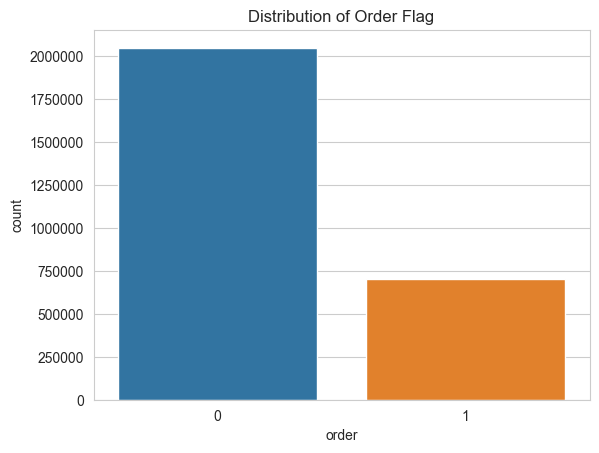

In [145]:
# Numbers
order_counts = df['order'].value_counts()
order_percentages = (df['order'].value_counts(normalize=True) * 100).round(2)
order_EDA = pd.DataFrame({'count': order_counts, 'percentage': order_percentages})
order_EDA.to_csv('../data/processed/order_EDA.csv', index=True)
print(order_EDA)

# Visualization
plot = sns.countplot(x="order", hue="order", data=df)
if plot.legend_ is not None:
    plot.legend_.remove()
plot.get_yaxis().get_major_formatter().set_scientific(False)
plt.title("Distribution of Order Flag")
plt.savefig('../reports/figures/order_EDA.png')
plt.show()

### Funnel Analysis

#### ***Basket***

        total_count  total_percentage  order_0_count  order_1_count  \
basket                                                                
0           2287917             83.02        1582827         705090   
1            468086             16.98         468086              0   

        order_0_percentage  order_1_percentage  
basket                                          
0                    69.18               30.82  
1                   100.00                0.00  


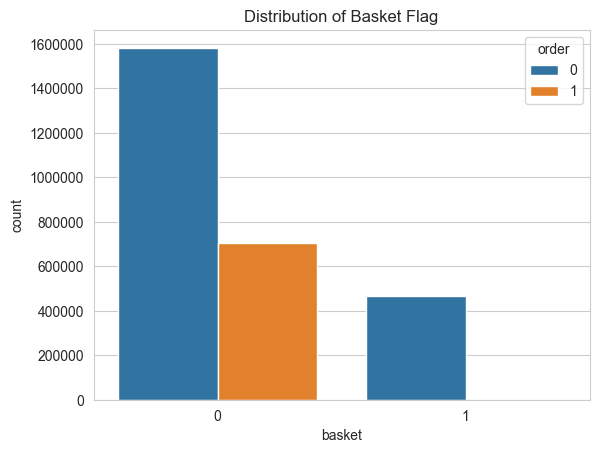

In [146]:
# Numbers
basket_counts = df['basket'].value_counts()
basket_percentages = (df['basket'].value_counts(normalize=True) * 100).round(2)
basket_order_ct = pd.crosstab(df['basket'], df['order'])
basket_order_ct_pct = (pd.crosstab(df['basket'], df['order'], normalize='index') * 100).round(2)
basket_EDA_df = pd.DataFrame({
    'total_count': basket_counts,
    'total_percentage': basket_percentages,
    'order_0_count': basket_order_ct[0],
    'order_1_count': basket_order_ct[1],
    'order_0_percentage': basket_order_ct_pct[0],
    'order_1_percentage': basket_order_ct_pct[1]
})
print(basket_EDA_df)
basket_EDA_df.to_csv('../data/processed/basket_EDA.csv', index=True)

# Visualization
plot = sns.countplot(x="basket", hue="order", data=df)
plot.get_yaxis().get_major_formatter().set_scientific(False)
plt.title("Distribution of Basket Flag")
plt.savefig('../reports/figures/basket_EDA.png')
plt.show()

#### ***Click***

       total_count  total_percentage  order_0_count  order_1_count  \
click                                                                
0          1173176             42.57         468086         705090   
1          1582827             57.43        1582827              0   

       order_0_percentage  order_1_percentage  
click                                          
0                    39.9                60.1  
1                   100.0                 0.0  


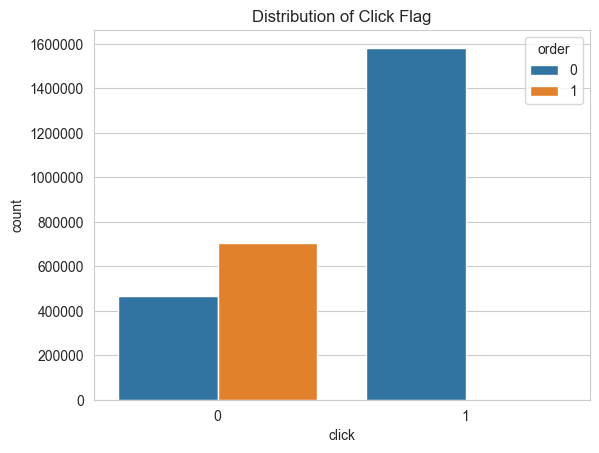

In [147]:
# Numbers
click_counts = df['click'].value_counts()
click_percentages = (df['click'].value_counts(normalize=True) * 100).round(2)
click_order_ct = pd.crosstab(df['click'], df['order'])
click_order_ct_pct = (pd.crosstab(df['click'], df['order'], normalize='index') * 100).round(2)
click_EDA_df = pd.DataFrame({
    'total_count': click_counts,
    'total_percentage': click_percentages,
    'order_0_count': click_order_ct[0],
    'order_1_count': click_order_ct[1],
    'order_0_percentage': click_order_ct_pct[0],
    'order_1_percentage': click_order_ct_pct[1]
})
print(click_EDA_df)
click_EDA_df.to_csv('../data/processed/click_EDA.csv', index=True)

# Visualization
plot = sns.countplot(x="click", hue="order", data=df)
plot.get_yaxis().get_major_formatter().set_scientific(False)
plt.title("Distribution of Click Flag")
plt.savefig('../reports/figures/click_EDA.png')
plt.show()

### Categorical Features

#### ***Pid***

- High-Cardinality Categorical Feature
- Long-tail distribution

Number of unique PIDs: 21928

Top 20 PIDs (and Others) by Interaction and Order Count:
order   total_event_count  total_event_percentage  order_count  \
2655                53785                    1.95          525   
2491                14666                    0.53         8473   
16641               12369                    0.45         4866   
16144               11134                    0.40         4739   
7403                10002                    0.36         4767   
3853                 8683                    0.32         3185   
1426                 8396                    0.30         4281   
1247                 7949                    0.29         2990   
1037                 7933                    0.29         4438   
1567                 7761                    0.28         3531   
11569                7526                    0.27         3355   
1145                 6833                    0.25         1314   
4070                 6522                    0.24      

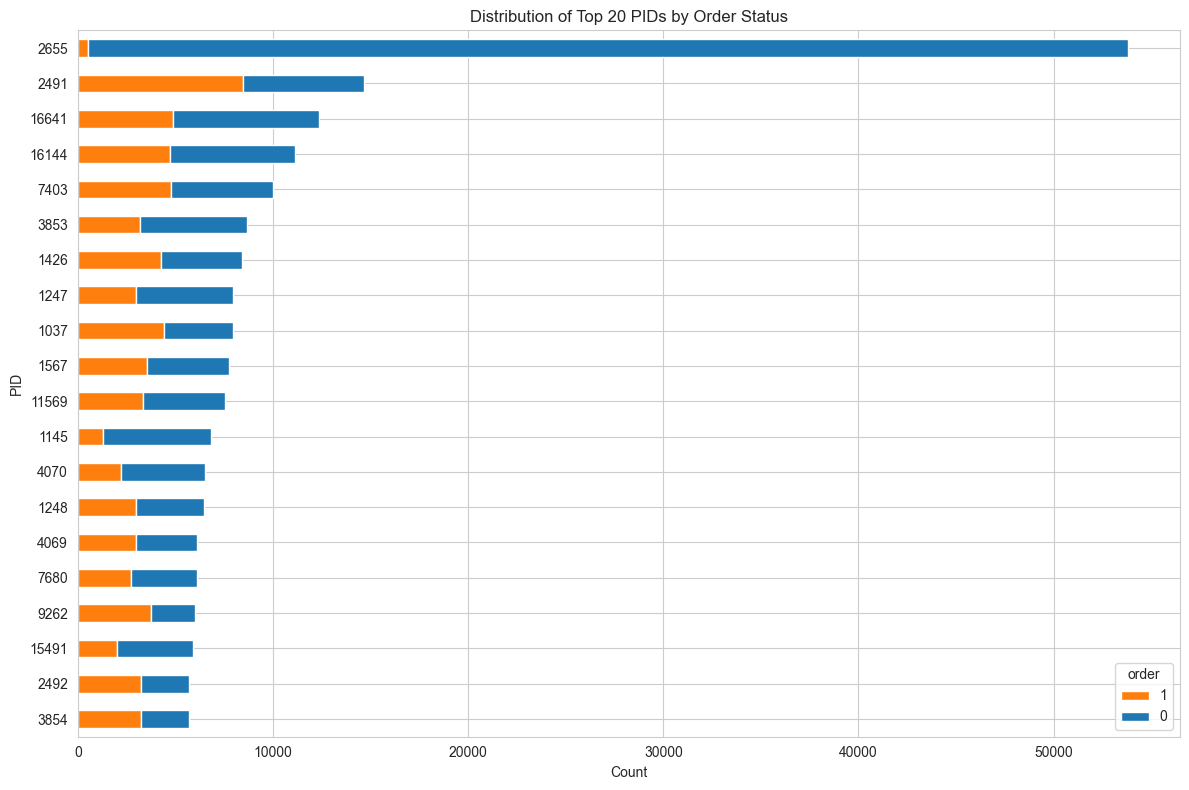

In [148]:
# Numbers
all_pid_counts_total = df['pid'].value_counts()
top_20_pids_list = all_pid_counts_total.head(20).index
all_pid_order_counts = df.pivot_table(index='pid', columns='order', aggfunc='size', fill_value=0)
all_pid_order_counts['total_events'] = all_pid_order_counts.sum(axis=1)
top_20_counts = all_pid_order_counts.loc[top_20_pids_list]
other_pids = all_pid_order_counts.drop(top_20_pids_list)
other_counts = other_pids.sum().to_frame('others').T
pid_EDA_df = pd.concat([top_20_counts, other_counts])
total_events = df.shape[0]
total_orders = df['order'].sum()
total_no_orders = total_events - total_orders
pid_EDA_df['total_event_percentage'] = (pid_EDA_df['total_events'] / total_events * 100).round(2)
pid_EDA_df['order_count'] = pid_EDA_df[1]
pid_EDA_df['order_percentage'] = (pid_EDA_df[1] / total_orders * 100).round(2)
pid_EDA_df['no_order_count'] = pid_EDA_df[0]
pid_EDA_df['no_order_percentage'] = (pid_EDA_df[0] / total_no_orders * 100).round(2)
pid_EDA_df = pid_EDA_df[['total_events', 'total_event_percentage', 'order_count', 'order_percentage', 'no_order_count', 'no_order_percentage']]
pid_EDA_df.rename(columns={'total_events': 'total_event_count'}, inplace=True)
pid_EDA_df.to_csv('../data/processed/pid_EDA.csv', index=True)
print("Number of unique PIDs:", df['pid'].unique().shape[0])
print("\nTop 20 PIDs (and Others) by Interaction and Order Count:")
print(pid_EDA_df)

# Visualization
top_20_pids_list_viz = df['pid'].value_counts().head(20).index
df_top20_pid = df[df['pid'].isin(top_20_pids_list_viz)]
pid_order_counts_viz = df_top20_pid.pivot_table(index='pid', columns='order', aggfunc='size', fill_value=0)
pid_order_counts_viz = pid_order_counts_viz.reindex(top_20_pids_list_viz)
pid_order_counts_viz = pid_order_counts_viz[[1, 0]]
colors = ['tab:orange', 'tab:blue']
pid_order_counts_viz.plot(kind='barh', stacked=True, figsize=(12, 8), color=colors)
plt.title('Distribution of Top 20 PIDs by Order Status')
plt.xlabel('Count')
plt.ylabel('PID')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/figures/pid_EDA.png')
plt.show()

#### ***Manufacturer***

- High-Cardinality Categorical Feature
- Long-tail distribution

Number of unique Manufacturers: 1065

Top 20 Manufacturers (and Others) by Interaction and Order Count:
order   total_event_count  total_event_percentage  order_count  \
84                 146079                    5.30        51815   
82                 111712                    4.05        37850   
18                 105665                    3.83        31848   
52                 104694                    3.80        36180   
156                 89827                    3.26         9527   
176                 77729                    2.82        26857   
105                 62011                    2.25        21884   
4                   55928                    2.03        20311   
37                  51836                    1.88        16909   
1                   51017                    1.85        13731   
89                  48303                    1.75        14663   
79                  44862                    1.63        10613   
47                  32082             

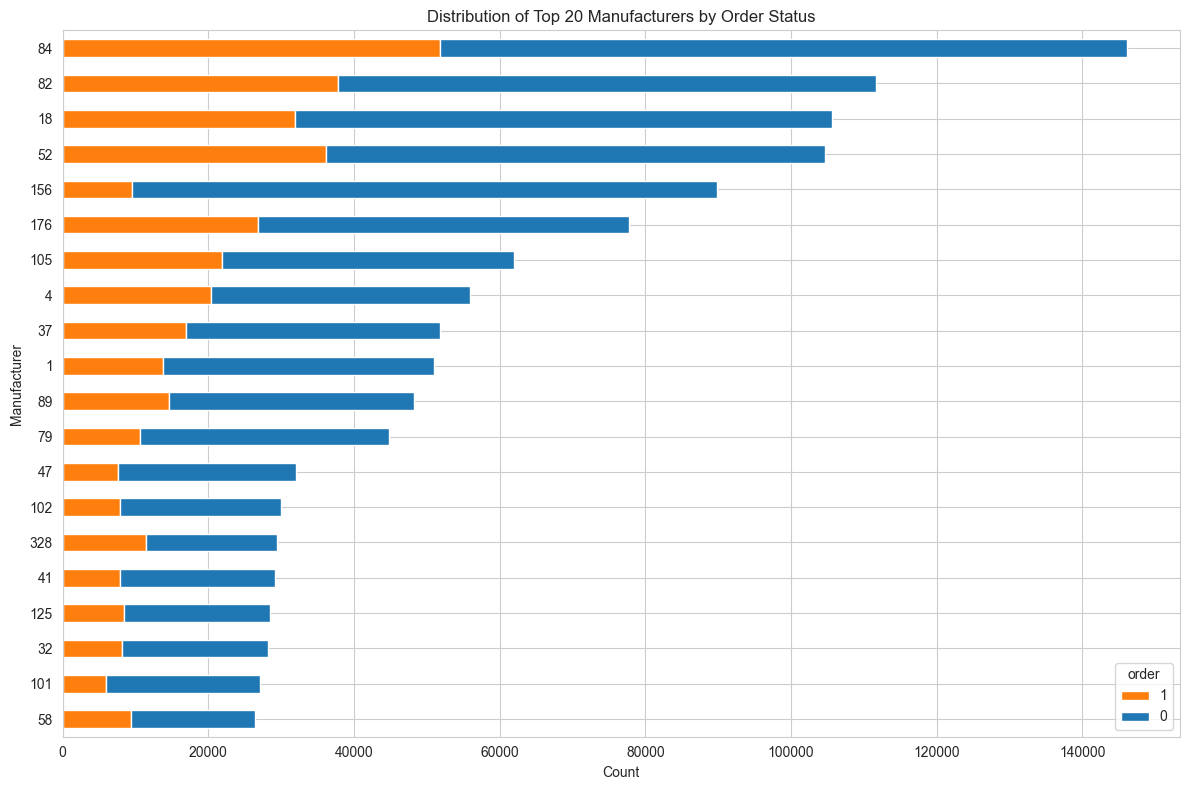

In [149]:
# Numbers
all_manufacturer_counts_total = df['manufacturer'].value_counts()
top_20_manufacturer_list = all_manufacturer_counts_total.head(20).index
all_manufacturer_order_counts = df.pivot_table(index='manufacturer', columns='order', aggfunc='size', fill_value=0)
all_manufacturer_order_counts['total_events'] = all_manufacturer_order_counts.sum(axis=1)
top_20_counts = all_manufacturer_order_counts.loc[top_20_manufacturer_list]
other_manufacturers = all_manufacturer_order_counts.drop(top_20_manufacturer_list)
other_counts = other_manufacturers.sum().to_frame('others').T
manufacturer_EDA_df = pd.concat([top_20_counts, other_counts])
total_events = df.shape[0]
total_orders = df['order'].sum()
total_no_orders = total_events - total_orders
manufacturer_EDA_df['total_event_percentage'] = (manufacturer_EDA_df['total_events'] / total_events * 100).round(2)
manufacturer_EDA_df['order_count'] = manufacturer_EDA_df[1]
manufacturer_EDA_df['order_percentage'] = (manufacturer_EDA_df[1] / total_orders * 100).round(2)
manufacturer_EDA_df['no_order_count'] = manufacturer_EDA_df[0]
manufacturer_EDA_df['no_order_percentage'] = (manufacturer_EDA_df[0] / total_no_orders * 100).round(2)
manufacturer_EDA_df = manufacturer_EDA_df[['total_events', 'total_event_percentage', 'order_count', 'order_percentage', 'no_order_count', 'no_order_percentage']]
manufacturer_EDA_df.rename(columns={'total_events': 'total_event_count'}, inplace=True)
manufacturer_EDA_df.to_csv('../data/processed/manufacturer_EDA.csv', index=True)
print("Number of unique Manufacturers:", df['manufacturer'].unique().shape[0])
print("\nTop 20 Manufacturers (and Others) by Interaction and Order Count:")
print(manufacturer_EDA_df)

# Visualization
top_20_manufacturers_list_viz = df['manufacturer'].value_counts().head(20).index
df_top20_manufacturer = df[df['manufacturer'].isin(top_20_manufacturers_list_viz)]
manufacturer_order_counts_viz = df_top20_manufacturer.pivot_table(index='manufacturer', columns='order', aggfunc='size', fill_value=0)
manufacturer_order_counts_viz = manufacturer_order_counts_viz.reindex(top_20_manufacturers_list_viz)
manufacturer_order_counts_viz = manufacturer_order_counts_viz[[1, 0]]
colors = ['tab:orange', 'tab:blue']
manufacturer_order_counts_viz.plot(kind='barh', stacked=True, figsize=(12, 8), color=colors)
plt.title('Distribution of Top 20 Manufacturers by Order Status')
plt.xlabel('Count')
plt.ylabel('Manufacturer')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/figures/manufacturer_EDA.png')
plt.show()

#### ***Content***

- High-Cardinality Categorical Feature
- Long-tail distribution

Number of unique Contents: 548

Top 20 Contents (and Others) by Interaction and Order Count:
order   total_event_count  total_event_percentage  order_count  \
50                 380869                   13.82        93724   
100                338015                   12.26        88553   
20                 312231                   11.33        94228   
10                 219805                    7.98        60632   
1                  167216                    6.07        27907   
30                 134279                    4.87        29102   
200                112206                    4.07        31677   
60                  87661                    3.18        17377   
40                  61460                    2.23        16410   
120                 59715                    2.17        12960   
150                 59096                    2.14        18270   
15                  58036                    2.11        19443   
25                  42682                    1.55

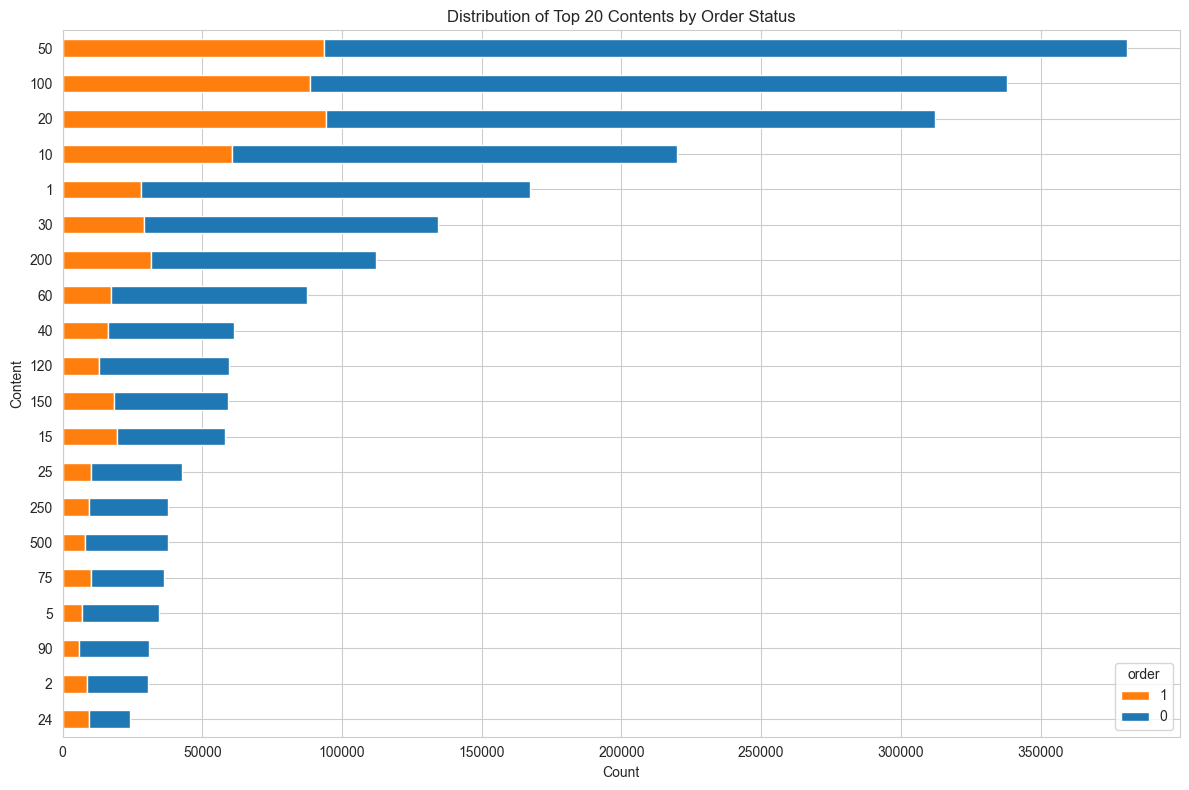

In [150]:
# Numbers
all_content_counts_total = df['content'].value_counts()
top_20_content_list = all_content_counts_total.head(20).index
all_content_order_counts = df.pivot_table(index='content', columns='order', aggfunc='size', fill_value=0)
all_content_order_counts['total_events'] = all_content_order_counts.sum(axis=1)
top_20_counts = all_content_order_counts.loc[top_20_content_list]
other_contents = all_content_order_counts.drop(top_20_content_list)
other_counts = other_contents.sum().to_frame('others').T
content_EDA_df = pd.concat([top_20_counts, other_counts])
total_events = df.shape[0]
total_orders = df['order'].sum()
total_no_orders = total_events - total_orders
content_EDA_df['total_event_percentage'] = (content_EDA_df['total_events'] / total_events * 100).round(2)
content_EDA_df['order_count'] = content_EDA_df[1]
content_EDA_df['order_percentage'] = (content_EDA_df[1] / total_orders * 100).round(2)
content_EDA_df['no_order_count'] = content_EDA_df[0]
content_EDA_df['no_order_percentage'] = (content_EDA_df[0] / total_no_orders * 100).round(2)
content_EDA_df = content_EDA_df[['total_events', 'total_event_percentage', 'order_count', 'order_percentage', 'no_order_count', 'no_order_percentage']]
content_EDA_df.rename(columns={'total_events': 'total_event_count'}, inplace=True)
content_EDA_df.to_csv('../data/processed/content_EDA.csv', index=True)
print("Number of unique Contents:", df['content'].unique().shape[0])
print("\nTop 20 Contents (and Others) by Interaction and Order Count:")
print(content_EDA_df)

# Visualization
top_20_contents_list_viz = df['content'].value_counts().head(20).index
df_top20_content = df[df['content'].isin(top_20_contents_list_viz)]
content_order_counts_viz = df_top20_content.pivot_table(index='content', columns='order', aggfunc='size', fill_value=0)
content_order_counts_viz = content_order_counts_viz.reindex(top_20_contents_list_viz)
content_order_counts_viz = content_order_counts_viz[[1, 0]]
colors = ['tab:orange', 'tab:blue']
content_order_counts_viz.plot(kind='barh', stacked=True, figsize=(12, 8), color=colors)
plt.title('Distribution of Top 20 Contents by Order Status')
plt.xlabel('Count')
plt.ylabel('Content')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/figures/content_EDA.png')
plt.show()

#### ***Group***

- High-Cardinality Categorical Feature
- Long-tail distribution

Number of unique Groups: 533

Top 20 Groups (and Others) by Interaction and Order Count:
order     total_event_count  total_event_percentage  order_count  \
22OI3                159787                    5.80        37760   
2FOI                 148449                    5.39        33843   
21OKG                110419                    4.01        15777   
18OI0EOI              96243                    3.49        36461   
21OK3                 71052                    2.58        14883   
1COS2                 55938                    2.03         1259   
1DOIF0ZO              47419                    1.72        11771   
18OZ00IS              46010                    1.67        15414   
1COI00OT              44421                    1.61        24334   
20OHG                 42005                    1.52         6452   
21OIG                 39180                    1.42         7626   
21OK2                 38194                    1.39        10557   
19OZ1ESI              34933

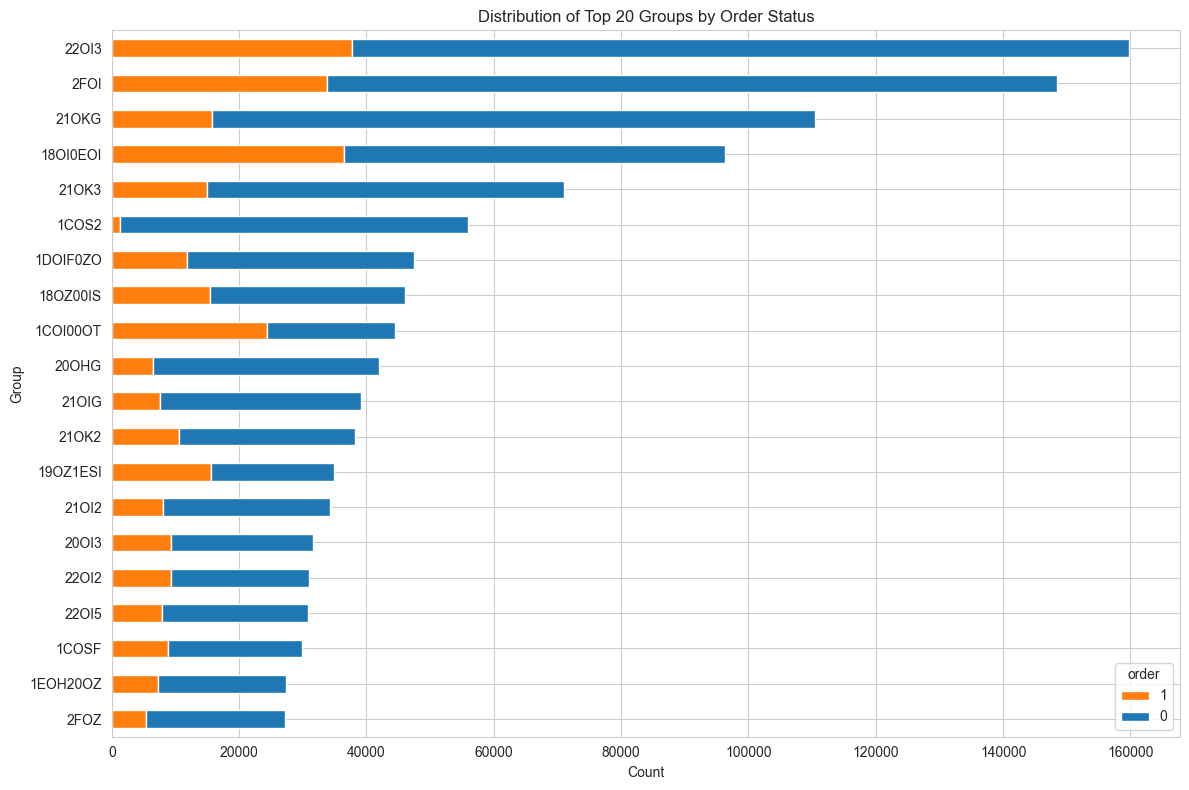

In [151]:
# Numbers
all_group_counts_total = df['group'].value_counts()
top_20_group_list = all_group_counts_total.head(20).index
all_group_order_counts = df.pivot_table(index='group', columns='order', aggfunc='size', fill_value=0)
all_group_order_counts['total_events'] = all_group_order_counts.sum(axis=1)
top_20_counts = all_group_order_counts.loc[top_20_group_list]
other_groups = all_group_order_counts.drop(top_20_group_list)
other_counts = other_groups.sum().to_frame('others').T
group_EDA_df = pd.concat([top_20_counts, other_counts])
total_events = df.shape[0]
total_orders = df['order'].sum()
total_no_orders = total_events - total_orders
group_EDA_df['total_event_percentage'] = (group_EDA_df['total_events'] / total_events * 100).round(2)
group_EDA_df['order_count'] = group_EDA_df[1]
group_EDA_df['order_percentage'] = (group_EDA_df[1] / total_orders * 100).round(2)
group_EDA_df['no_order_count'] = group_EDA_df[0]
group_EDA_df['no_order_percentage'] = (group_EDA_df[0] / total_no_orders * 100).round(2)
group_EDA_df = group_EDA_df[['total_events', 'total_event_percentage', 'order_count', 'order_percentage', 'no_order_count', 'no_order_percentage']]
group_EDA_df.rename(columns={'total_events': 'total_event_count'}, inplace=True)
group_EDA_df.to_csv('../data/processed/group_EDA.csv', index=True)
print("Number of unique Groups:", df['group'].unique().shape[0])
print("\nTop 20 Groups (and Others) by Interaction and Order Count:")
print(group_EDA_df)

# Visualization
top_20_groups_list_viz = df['group'].value_counts().head(20).index
df_top20_group = df[df['group'].isin(top_20_groups_list_viz)]
group_order_counts_viz = df_top20_group.pivot_table(index='group', columns='order', aggfunc='size', fill_value=0)
group_order_counts_viz = group_order_counts_viz.reindex(top_20_groups_list_viz)
group_order_counts_viz = group_order_counts_viz[[1, 0]]
colors = ['tab:orange', 'tab:blue']
group_order_counts_viz.plot(kind='barh', stacked=True, figsize=(12, 8), color=colors)
plt.title('Distribution of Top 20 Groups by Order Status')
plt.xlabel('Count')
plt.ylabel('Group')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/figures/group_EDA.png')
plt.show()

#### ***Pharm Form***

- High-Cardinality Categorical Feature
- Long-tail distribution

Number of unique PharmForms: 279

Top 20 PharmForms (and Others) by Interaction and Order Count:
order   total_event_count  total_event_percentage  order_count  \
TAB                252906                    9.18        75806   
CRE                196138                    7.12        50931   
FTA                182441                    6.62        57067   
GEL                147438                    5.35        43186   
KAP                141001                    5.12        24962   
LOE                129541                    4.70        31572   
FLU                105811                    3.84        14806   
SAL                 97753                    3.55        24887   
SPR                 62256                    2.26        13196   
NAS                 54770                    1.99        26229   
PUL                 54431                    1.97        10053   
ATR                 52477                    1.90        12901   
HKP                 51584                    

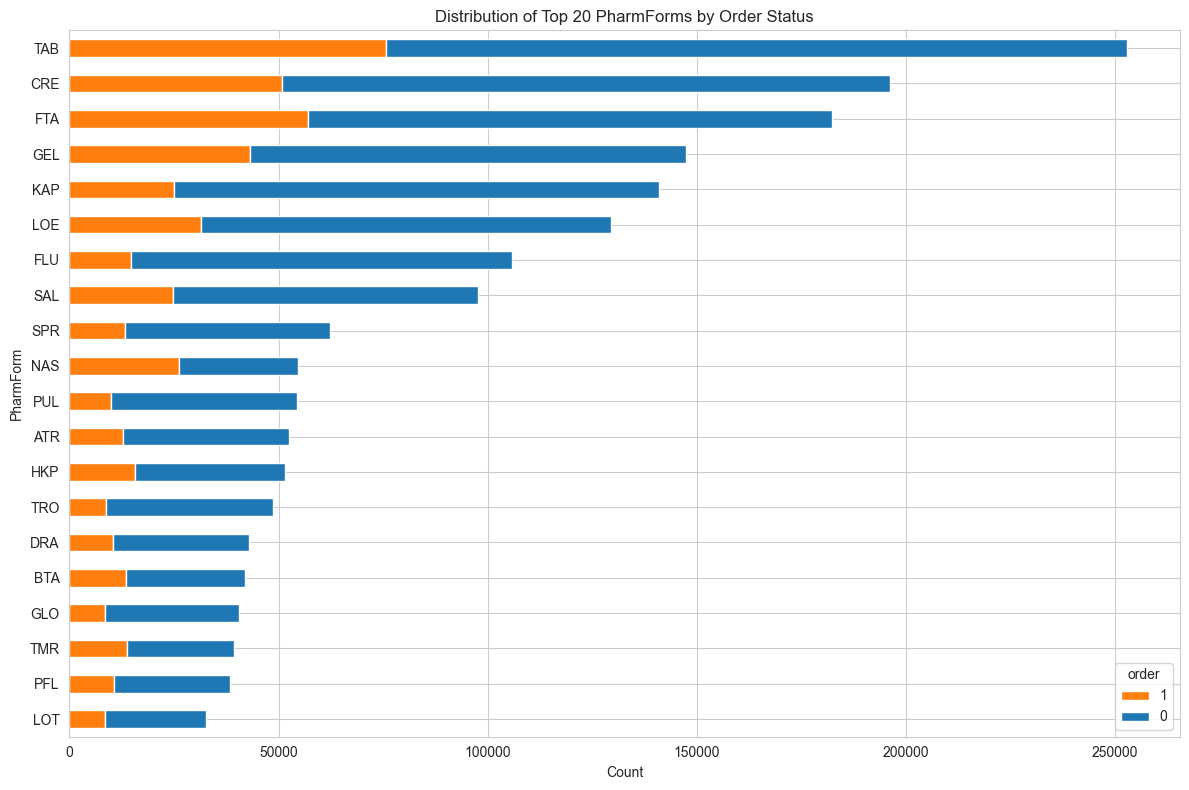

In [152]:
# Numbers
all_pharmForm_counts_total = df['pharmForm'].value_counts()
top_20_pharmForm_list = all_pharmForm_counts_total.head(20).index
all_pharmForm_order_counts = df.pivot_table(index='pharmForm', columns='order', aggfunc='size', fill_value=0)
all_pharmForm_order_counts['total_events'] = all_pharmForm_order_counts.sum(axis=1)
top_20_counts = all_pharmForm_order_counts.loc[top_20_pharmForm_list]
other_pharmForms = all_pharmForm_order_counts.drop(top_20_pharmForm_list)
other_counts = other_pharmForms.sum().to_frame('others').T
pharmForm_EDA_df = pd.concat([top_20_counts, other_counts])
total_events = df.shape[0]
total_orders = df['order'].sum()
total_no_orders = total_events - total_orders
pharmForm_EDA_df['total_event_percentage'] = (pharmForm_EDA_df['total_events'] / total_events * 100).round(2)
pharmForm_EDA_df['order_count'] = pharmForm_EDA_df[1]
pharmForm_EDA_df['order_percentage'] = (pharmForm_EDA_df[1] / total_orders * 100).round(2)
pharmForm_EDA_df['no_order_count'] = pharmForm_EDA_df[0]
pharmForm_EDA_df['no_order_percentage'] = (pharmForm_EDA_df[0] / total_no_orders * 100).round(2)
pharmForm_EDA_df = pharmForm_EDA_df[['total_events', 'total_event_percentage', 'order_count', 'order_percentage', 'no_order_count', 'no_order_percentage']]
pharmForm_EDA_df.rename(columns={'total_events': 'total_event_count'}, inplace=True)
pharmForm_EDA_df.to_csv('../data/processed/pharmForm_EDA.csv', index=True)
print("Number of unique PharmForms:", df['pharmForm'].unique().shape[0])
print("\nTop 20 PharmForms (and Others) by Interaction and Order Count:")
print(pharmForm_EDA_df)

# Visualization
top_20_pharmForms_list_viz = df['pharmForm'].value_counts().head(20).index
df_top20_pharmForm = df[df['pharmForm'].isin(top_20_pharmForms_list_viz)]
pharmForm_order_counts_viz = df_top20_pharmForm.pivot_table(index='pharmForm', columns='order', aggfunc='size', fill_value=0)
pharmForm_order_counts_viz = pharmForm_order_counts_viz.reindex(top_20_pharmForms_list_viz)
pharmForm_order_counts_viz = pharmForm_order_counts_viz[[1, 0]]
colors = ['tab:orange', 'tab:blue']
pharmForm_order_counts_viz.plot(kind='barh', stacked=True, figsize=(12, 8), color=colors)
plt.title('Distribution of Top 20 PharmForms by Order Status')
plt.xlabel('Count')
plt.ylabel('PharmForm')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/figures/pharmForm_EDA.png')
plt.show()

#### ***Category***

- High-Cardinality Categorical Feature
- Long-tail distribution

Number of unique Categories: 410

Top 20 Categories (and Others) by Interaction and Order Count:
order   total_event_count  total_event_percentage  order_count  \
50.0               118323                    4.29        46943   
66.0                65987                    2.39        28266   
90.0                64779                    2.35        18970   
101.0               63884                    2.32        16413   
116.0               62340                    2.26         3360   
25.0                61986                    2.25        18057   
132.0               50639                    1.84        23694   
9.0                 47142                    1.71        12959   
12.0                42829                    1.55        11568   
39.0                42281                    1.53        10748   
71.0                40925                    1.48        13675   
46.0                40681                    1.48        11542   
121.0               40008                    

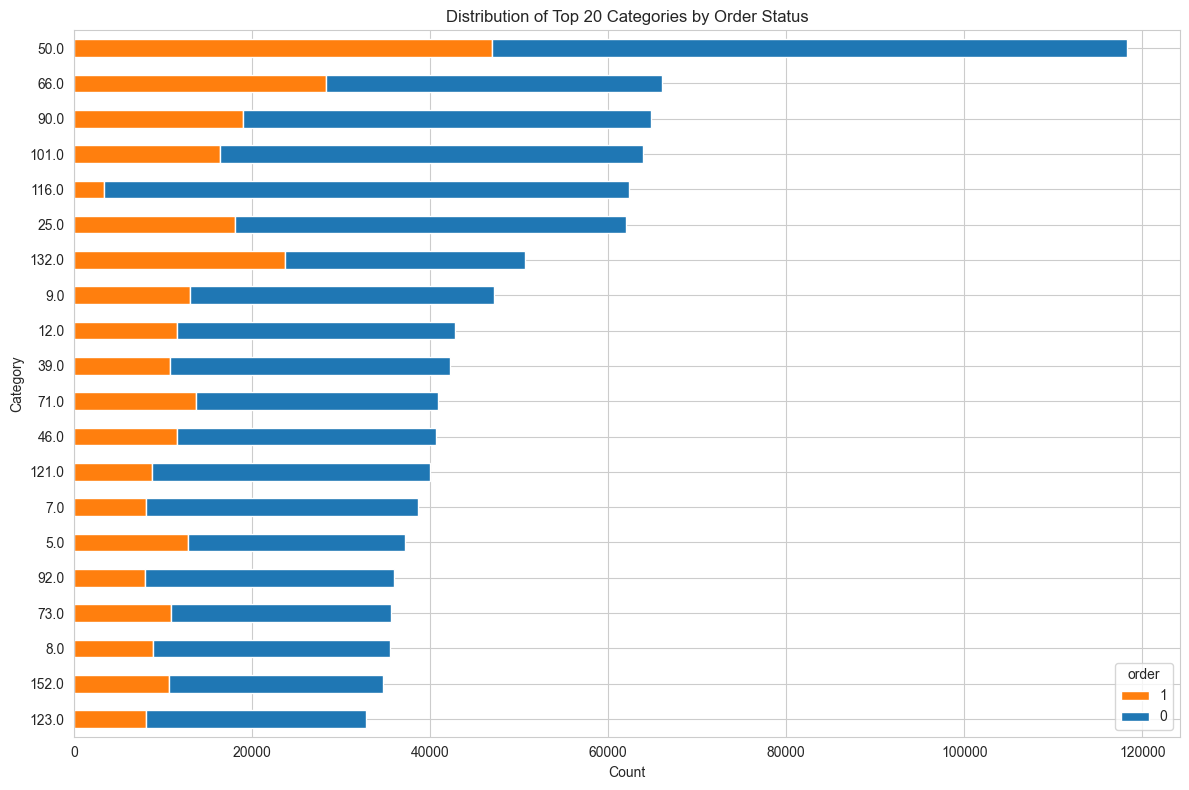

In [153]:
# Numbers
all_category_counts_total = df['category'].value_counts()
top_20_category_list = all_category_counts_total.head(20).index
all_category_order_counts = df.pivot_table(index='category', columns='order', aggfunc='size', fill_value=0)
all_category_order_counts['total_events'] = all_category_order_counts.sum(axis=1)
top_20_counts = all_category_order_counts.loc[top_20_category_list]
other_categories = all_category_order_counts.drop(top_20_category_list)
other_counts = other_categories.sum().to_frame('others').T
category_EDA_df = pd.concat([top_20_counts, other_counts])
total_events = df.shape[0]
total_orders = df['order'].sum()
total_no_orders = total_events - total_orders
category_EDA_df['total_event_percentage'] = (category_EDA_df['total_events'] / total_events * 100).round(2)
category_EDA_df['order_count'] = category_EDA_df[1]
category_EDA_df['order_percentage'] = (category_EDA_df[1] / total_orders * 100).round(2)
category_EDA_df['no_order_count'] = category_EDA_df[0]
category_EDA_df['no_order_percentage'] = (category_EDA_df[0] / total_no_orders * 100).round(2)
category_EDA_df = category_EDA_df[['total_events', 'total_event_percentage', 'order_count', 'order_percentage', 'no_order_count', 'no_order_percentage']]
category_EDA_df.rename(columns={'total_events': 'total_event_count'}, inplace=True)
category_EDA_df.to_csv('../data/processed/category_EDA.csv', index=True)
print("Number of unique Categories:", df['category'].unique().shape[0])
print("\nTop 20 Categories (and Others) by Interaction and Order Count:")
print(category_EDA_df)

# Visualization
top_20_categories_list_viz = df['category'].value_counts().head(20).index
df_top20_category = df[df['category'].isin(top_20_categories_list_viz)]
category_order_counts_viz = df_top20_category.pivot_table(index='category', columns='order', aggfunc='size', fill_value=0)
category_order_counts_viz = category_order_counts_viz.reindex(top_20_categories_list_viz)
category_order_counts_viz = category_order_counts_viz[[1, 0]]
colors = ['tab:orange', 'tab:blue']
category_order_counts_viz.plot(kind='barh', stacked=True, figsize=(12, 8), color=colors)
plt.title('Distribution of Top 20 Categories by Order Status')
plt.xlabel('Count')
plt.ylabel('Category')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/figures/category_EDA.png')
plt.show()

#### ***Day***

     total_count  total_percentage  order_0_count  order_1_count  \
day                                                                
1          18358              0.67          11888           6470   
2          17331              0.63          11308           6023   
3          24669              0.90          14854           9815   
4          24833              0.90          15075           9758   
5          26520              0.96          16845           9675   
..           ...               ...            ...            ...   
88         40787              1.48          30550          10237   
89         37257              1.35          27819           9438   
90         36187              1.31          26756           9431   
91         33719              1.22          24875           8844   
92         30896              1.12          23835           7061   

     order_0_percentage  order_1_percentage  
day                                          
1                 64.76

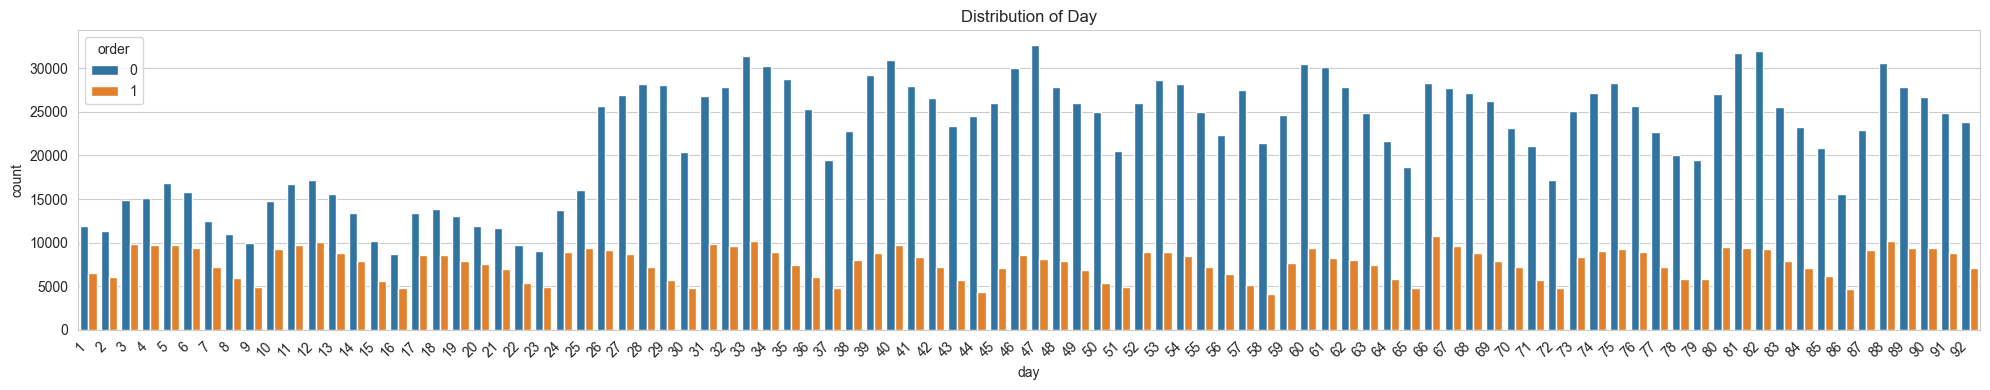

In [154]:
# Numbers
day_counts = df['day'].value_counts()
day_percentages = (df['day'].value_counts(normalize=True) * 100).round(2)
day_order_ct = pd.crosstab(df['day'], df['order'])
day_order_ct_pct = (pd.crosstab(df['day'], df['order'], normalize='index') * 100).round(2)
day_EDA_df = pd.DataFrame({
    'total_count': day_counts,
    'total_percentage': day_percentages,
    'order_0_count': day_order_ct[0],
    'order_1_count': day_order_ct[1],
    'order_0_percentage': day_order_ct_pct[0],
    'order_1_percentage': day_order_ct_pct[1]
})
print(day_EDA_df)
day_EDA_df.to_csv('../data/processed/day_EDA.csv', index=True)

# Visualization
plt.figure(figsize=(20, 4))
plot = sns.countplot(data=df, x="day", hue="order")
plot.set_title("Distribution of Day")
plot.tick_params(axis="x", labelrotation=45)
for label in plot.get_xticklabels():
    label.set_ha("right")
plt.tight_layout()
plt.savefig('../reports/figures/day_EDA.png')
plt.show()

#### ***Ad Flag***

        total_count  total_percentage  order_0_count  order_1_count  \
adFlag                                                                
0           1880176             68.22        1457449         422727   
1            875827             31.78         593464         282363   

        order_0_percentage  order_1_percentage  
adFlag                                          
0                    77.52               22.48  
1                    67.76               32.24  


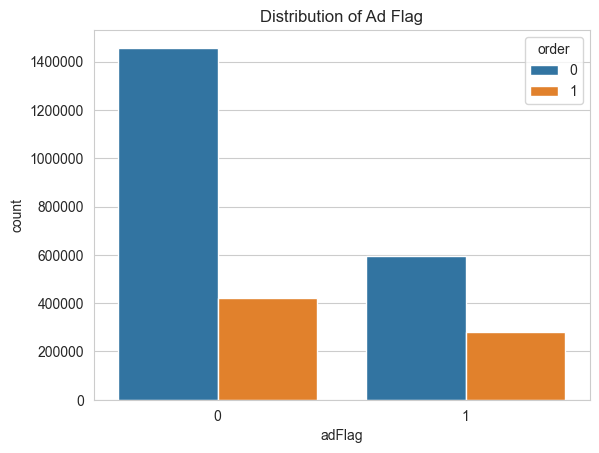

In [155]:
# Numbers
adFlag_counts = df['adFlag'].value_counts()
adFlag_percentages = (df['adFlag'].value_counts(normalize=True) * 100).round(2)
adFlag_order_ct = pd.crosstab(df['adFlag'], df['order'])
adFlag_order_ct_pct = (pd.crosstab(df['adFlag'], df['order'], normalize='index') * 100).round(2)
adFlag_EDA_df = pd.DataFrame({
    'total_count': adFlag_counts,
    'total_percentage': adFlag_percentages,
    'order_0_count': adFlag_order_ct[0],
    'order_1_count': adFlag_order_ct[1],
    'order_0_percentage': adFlag_order_ct_pct[0],
    'order_1_percentage': adFlag_order_ct_pct[1]
})
print(adFlag_EDA_df)
adFlag_EDA_df.to_csv('../data/processed/adFlag_EDA.csv', index=True)

# Visualization
plot = sns.countplot(x="adFlag", hue="order", data=df)
plot.get_yaxis().get_major_formatter().set_scientific(False)
plt.title("Distribution of Ad Flag")
plt.savefig('../reports/figures/adFlag_EDA.png')
plt.show()

#### ***Availability***

              total_count  total_percentage  order_0_count  order_1_count  \
availability                                                                
1                 2515572             91.28        1842116         673456   
2                  185194              6.72         158214          26980   
3                   44893              1.63          40242           4651   
4                   10344              0.38          10341              3   

              order_0_percentage  order_1_percentage  
availability                                          
1                          73.23               26.77  
2                          85.43               14.57  
3                          89.64               10.36  
4                          99.97                0.03  


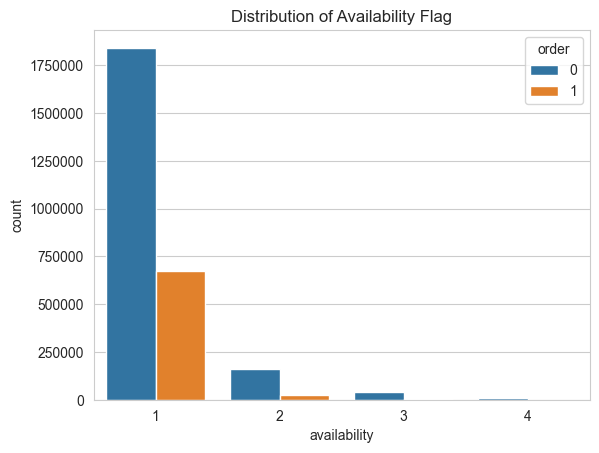

In [156]:
# Numbers
availability_counts = df['availability'].value_counts()
availability_percentages = (df['availability'].value_counts(normalize=True) * 100).round(2)
availability_order_ct = pd.crosstab(df['availability'], df['order'])
availability_order_ct_pct = (pd.crosstab(df['availability'], df['order'], normalize='index') * 100).round(2)
availability_EDA_df = pd.DataFrame({
    'total_count': availability_counts,
    'total_percentage': availability_percentages,
    'order_0_count': availability_order_ct[0],
    'order_1_count': availability_order_ct[1],
    'order_0_percentage': availability_order_ct_pct[0],
    'order_1_percentage': availability_order_ct_pct[1]
})
print(availability_EDA_df)
availability_EDA_df.to_csv('../data/processed/availability_EDA.csv', index=True)

# Visualization
plot = sns.countplot(x="availability", hue="order", data=df)
plot.get_yaxis().get_major_formatter().set_scientific(False)
plt.title("Distribution of Availability Flag")
plt.savefig('../reports/figures/availability_EDA.png')
plt.show()

#### ***Unit***

      total_count  total_percentage  order_0_count  order_1_count  \
unit                                                                
CM            272              0.01            247             25   
G          472390             17.14         346456         125934   
KG            178              0.01            134             44   
L            2613              0.09           1984            629   
M             591              0.02            396            195   
ML         927879             33.67         702217         225662   
P           19824              0.72          16929           2895   
ST        1332256             48.34         982550         349706   

      order_0_percentage  order_1_percentage  
unit                                          
CM                 90.81                9.19  
G                  73.34               26.66  
KG                 75.28               24.72  
L                  75.93               24.07  
M                  67.01   

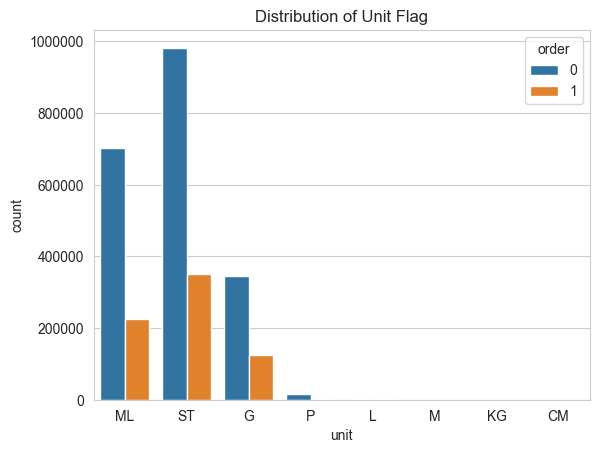

In [157]:
# Numbers
unit_counts = df['unit'].value_counts()
unit_percentages = (df['unit'].value_counts(normalize=True) * 100).round(2)
unit_order_ct = pd.crosstab(df['unit'], df['order'])
unit_order_ct_pct = (pd.crosstab(df['unit'], df['order'], normalize='index') * 100).round(2)
unit_EDA_df = pd.DataFrame({
    'total_count': unit_counts,
    'total_percentage': unit_percentages,
    'order_0_count': unit_order_ct[0],
    'order_1_count': unit_order_ct[1],
    'order_0_percentage': unit_order_ct_pct[0],
    'order_1_percentage': unit_order_ct_pct[1]
})
print(unit_EDA_df)
unit_EDA_df.to_csv('../data/processed/unit_EDA.csv', index=True)

# Visualization
plot = sns.countplot(x="unit", hue="order", data=df)
plot.get_yaxis().get_major_formatter().set_scientific(False)
plt.title("Distribution of Unit Flag")
plt.savefig('../reports/figures/unit_EDA.png')
plt.show()

#### ***Generic Product***

                total_count  total_percentage  order_0_count  order_1_count  \
genericProduct                                                                
0                   2465221             89.45        1869403         595818   
1                    290782             10.55         181510         109272   

                order_0_percentage  order_1_percentage  
genericProduct                                          
0                            75.83               24.17  
1                            62.42               37.58  


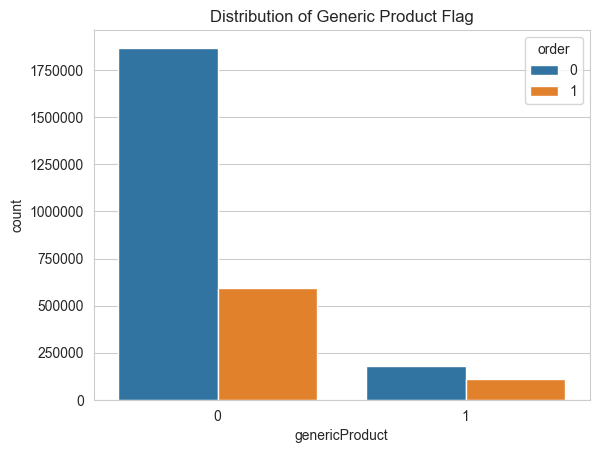

In [170]:
# Numbers
genericProduct_counts = df['genericProduct'].value_counts()
genericProduct_percentages = (df['genericProduct'].value_counts(normalize=True) * 100).round(2)
genericProduct_order_ct = pd.crosstab(df['genericProduct'], df['order'])
genericProduct_order_ct_pct = (pd.crosstab(df['genericProduct'], df['order'], normalize='index') * 100).round(2)
genericProduct_EDA_df = pd.DataFrame({
    'total_count': genericProduct_counts,
    'total_percentage': genericProduct_percentages,
    'order_0_count': genericProduct_order_ct[0],
    'order_1_count': genericProduct_order_ct[1],
    'order_0_percentage': genericProduct_order_ct_pct[0],
    'order_1_percentage': genericProduct_order_ct_pct[1]
})
print(genericProduct_EDA_df)
genericProduct_EDA_df.to_csv('../data/processed/genericProduct_EDA.csv', index=True)

# Visualization
plot = sns.countplot(x="genericProduct", hue="order", data=df)
plot.get_yaxis().get_major_formatter().set_scientific(False)
plt.title("Distribution of Generic Product Flag")
plt.savefig('../reports/figures/genericProduct_EDA.png')
plt.show()

#### ***Sales Index***

            total_count  total_percentage  order_0_count  order_1_count  \
salesIndex                                                                
40              1398720             50.75         994237         404483   
44                36402              1.32          29504           6898   
52               106734              3.87          81086          25648   
53              1214147             44.05         946086         268061   

            order_0_percentage  order_1_percentage  
salesIndex                                          
40                       71.08               28.92  
44                       81.05               18.95  
52                       75.97               24.03  
53                       77.92               22.08  


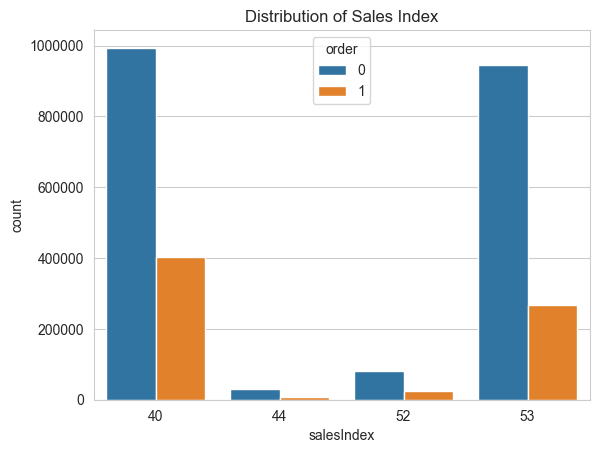

In [169]:
# Numbers
salesIndex_counts = df['salesIndex'].value_counts()
salesIndex_percentages = (df['salesIndex'].value_counts(normalize=True) * 100).round(2)
salesIndex_order_ct = pd.crosstab(df['salesIndex'], df['order'])
salesIndex_order_ct_pct = (pd.crosstab(df['salesIndex'], df['order'], normalize='index') * 100).round(2)
salesIndex_EDA_df = pd.DataFrame({
    'total_count': salesIndex_counts,
    'total_percentage': salesIndex_percentages,
    'order_0_count': salesIndex_order_ct[0],
    'order_1_count': salesIndex_order_ct[1],
    'order_0_percentage': salesIndex_order_ct_pct[0],
    'order_1_percentage': salesIndex_order_ct_pct[1]
})
print(salesIndex_EDA_df)
salesIndex_EDA_df.to_csv('../data/processed/salesIndex_EDA.csv', index=True)

# Visualization
plot = sns.countplot(x="salesIndex", hue="order", data=df)
plot.get_yaxis().get_major_formatter().set_scientific(False)
plt.title("Distribution of Sales Index")
plt.savefig('../reports/figures/salesIndex_EDA.png')
plt.show()

#### ***Campaign Index***

               total_count  total_percentage  order_0_count  order_1_count  \
campaignIndex                                                                
A                   144010             30.77          98601          45409   
B                   251965             53.83         187829          64136   
C                    72060             15.40          53138          18922   

               order_0_percentage  order_1_percentage  
campaignIndex                                          
A                           68.47               31.53  
B                           74.55               25.45  
C                           73.74               26.26  


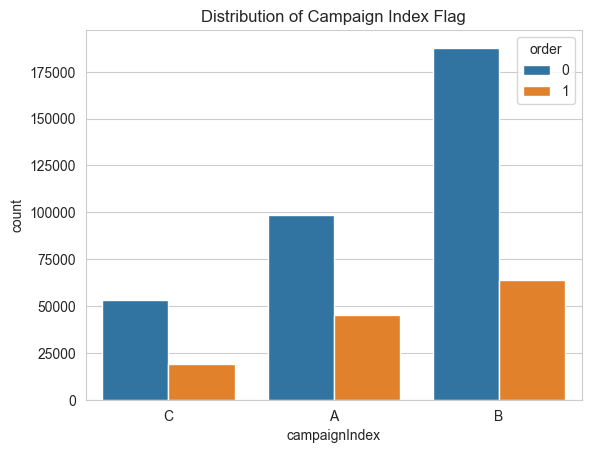

In [160]:
# Numbers
campaignIndex_counts = df['campaignIndex'].value_counts()
campaignIndex_percentages = (df['campaignIndex'].value_counts(normalize=True) * 100).round(2)
campaignIndex_order_ct = pd.crosstab(df['campaignIndex'], df['order'])
campaignIndex_order_ct_pct = (pd.crosstab(df['campaignIndex'], df['order'], normalize='index') * 100).round(2)
campaignIndex_EDA_df = pd.DataFrame({
    'total_count': campaignIndex_counts,
    'total_percentage': campaignIndex_percentages,
    'order_0_count': campaignIndex_order_ct[0],
    'order_1_count': campaignIndex_order_ct[1],
    'order_0_percentage': campaignIndex_order_ct_pct[0],
    'order_1_percentage': campaignIndex_order_ct_pct[1]
})
print(campaignIndex_EDA_df)
campaignIndex_EDA_df.to_csv('../data/processed/campaignIndex_EDA.csv', index=True)

# Visualization
plot = sns.countplot(x="campaignIndex", hue="order", data=df)
plot.get_yaxis().get_major_formatter().set_scientific(False)
plt.title("Distribution of Campaign Index Flag")
plt.savefig('../reports/figures/campaignIndex_EDA.png')
plt.show()

### Numerical Features

#### ***Price***

        total_count  total_percentage  order_0_count  order_1_count  \
price                                                                 
0.02              2               0.0              2              0   
0.03              8               0.0              7              1   
0.04              4               0.0              4              0   
0.06              1               0.0              1              0   
0.07             66               0.0             33             33   
...             ...               ...            ...            ...   
334.01            1               0.0              1              0   
340.64            1               0.0              1              0   
372.72            1               0.0              1              0   
374.59            4               0.0              3              1   
378.84            1               0.0              1              0   

        order_0_percentage  order_1_percentage  
price                      

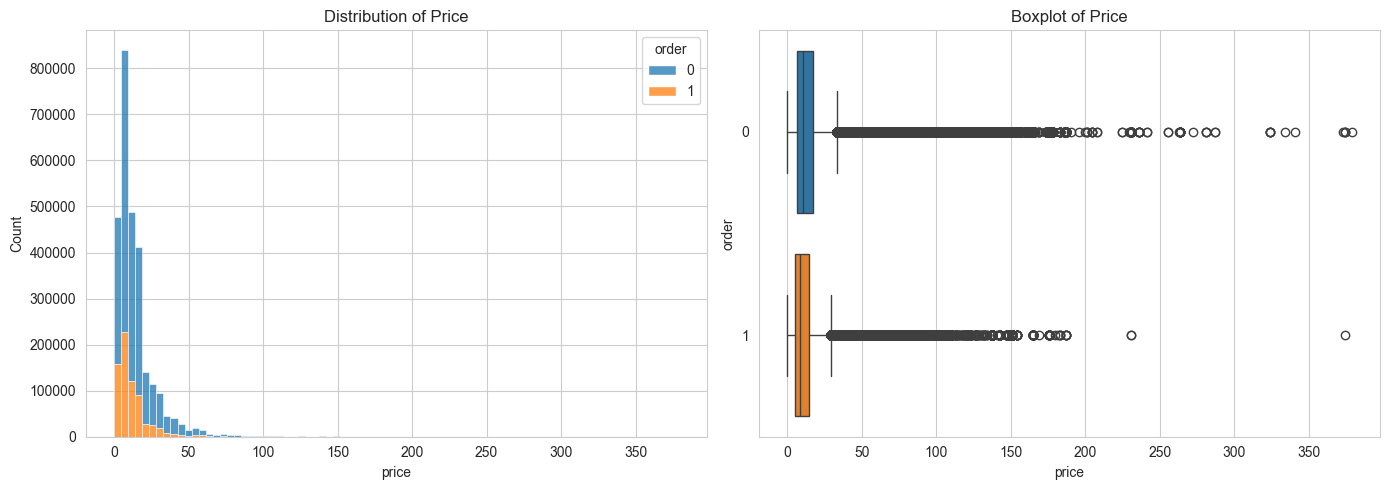

In [182]:
# Numbers
price_counts = df['price'].value_counts()
price_percentages = (df['price'].value_counts(normalize=True) * 100).round(2)
price_order_ct = pd.crosstab(df['price'], df['order'])
price_order_ct_pct = (pd.crosstab(df['price'], df['order'], normalize='index') * 100).round(2)
price_EDA_df = pd.DataFrame({
    'total_count': price_counts,
    'total_percentage': price_percentages,
    'order_0_count': price_order_ct[0],
    'order_1_count': price_order_ct[1],
    'order_0_percentage': price_order_ct_pct[0],
    'order_1_percentage': price_order_ct_pct[1]
})
print(price_EDA_df)
price_EDA_df.to_csv('../data/processed/price_EDA.csv', index=True)
print(df['price'].describe().apply('{0:.2f}'.format))

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df, x='price', hue='order', bins=80, multiple='stack', palette='tab10', ax=axes[0])
axes[0].set_title("Distribution of Price")
sns.boxplot(data=df, x='price', y='order', hue='order', palette='tab10', orient='h', ax=axes[1], legend=False)
axes[1].set_title("Boxplot of Price")
plt.tight_layout()
plt.savefig('../reports/figures/price_EDA.png')
plt.show()

#### ***Revenue***

        total_count  total_percentage  order_0_count  order_1_count  \
price                                                                 
0.02              2               0.0              2              0   
0.03              8               0.0              7              1   
0.04              4               0.0              4              0   
0.06              1               0.0              1              0   
0.07             66               0.0             33             33   
...             ...               ...            ...            ...   
334.01            1               0.0              1              0   
340.64            1               0.0              1              0   
372.72            1               0.0              1              0   
374.59            4               0.0              3              1   
378.84            1               0.0              1              0   

        order_0_percentage  order_1_percentage  
price                      

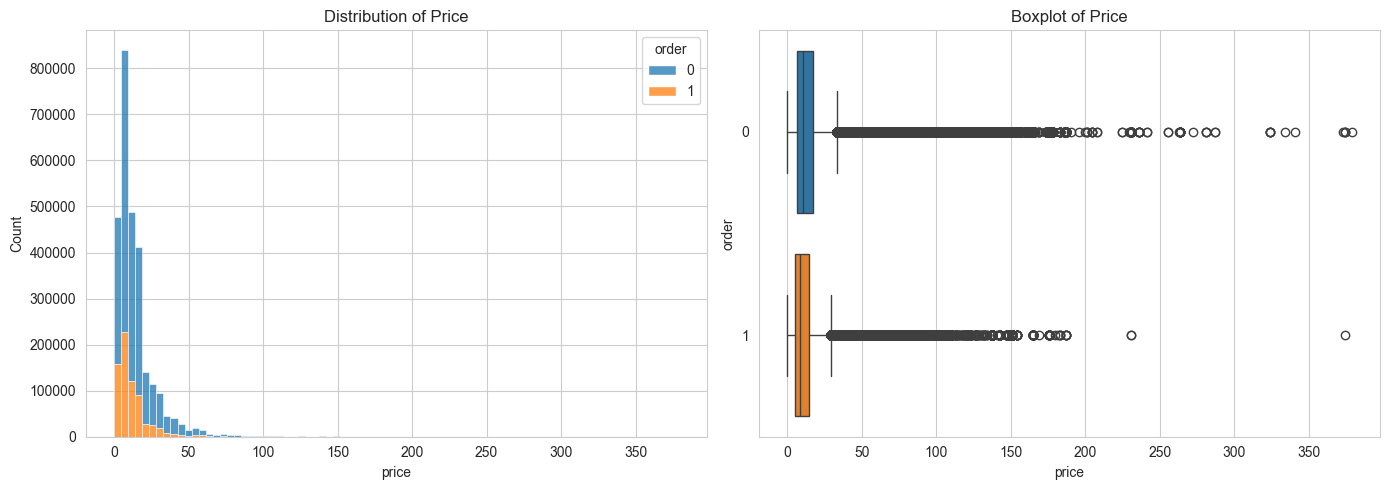

In [181]:
# Numbers
revenue_counts = df['price'].value_counts()
revenue_percentages = (df['price'].value_counts(normalize=True) * 100).round(2)
revenue_order_ct = pd.crosstab(df['price'], df['order'])
revenue_order_ct_pct = (pd.crosstab(df['price'], df['order'], normalize='index') * 100).round(2)
revenue_EDA_df = pd.DataFrame({
    'total_count': revenue_counts,
    'total_percentage': revenue_percentages,
    'order_0_count': revenue_order_ct[0],
    'order_1_count': revenue_order_ct[1],
    'order_0_percentage': revenue_order_ct_pct[0],
    'order_1_percentage': revenue_order_ct_pct[1]
})
print(revenue_EDA_df)
revenue_EDA_df.to_csv('../data/processed/revenue_EDA.csv', index=True)
print(df['revenue'].describe().apply('{0:.2f}'.format))

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df, x='price', hue='order', bins=80, multiple='stack', palette='tab10', ax=axes[0])
axes[0].set_title("Distribution of Price")
sns.boxplot(data=df, x='price', y='order', hue='order', palette='tab10', orient='h', ax=axes[1], legend=False)
axes[1].set_title("Boxplot of Price")
plt.tight_layout()
plt.savefig('../reports/figures/revenue_EDA.png')
plt.show()

#### ***Reference Price***

        total_count  total_percentage  order_0_count  order_1_count  \
price                                                                 
0.02              2               0.0              2              0   
0.03              8               0.0              7              1   
0.04              4               0.0              4              0   
0.06              1               0.0              1              0   
0.07             66               0.0             33             33   
...             ...               ...            ...            ...   
334.01            1               0.0              1              0   
340.64            1               0.0              1              0   
372.72            1               0.0              1              0   
374.59            4               0.0              3              1   
378.84            1               0.0              1              0   

        order_0_percentage  order_1_percentage  
price                      

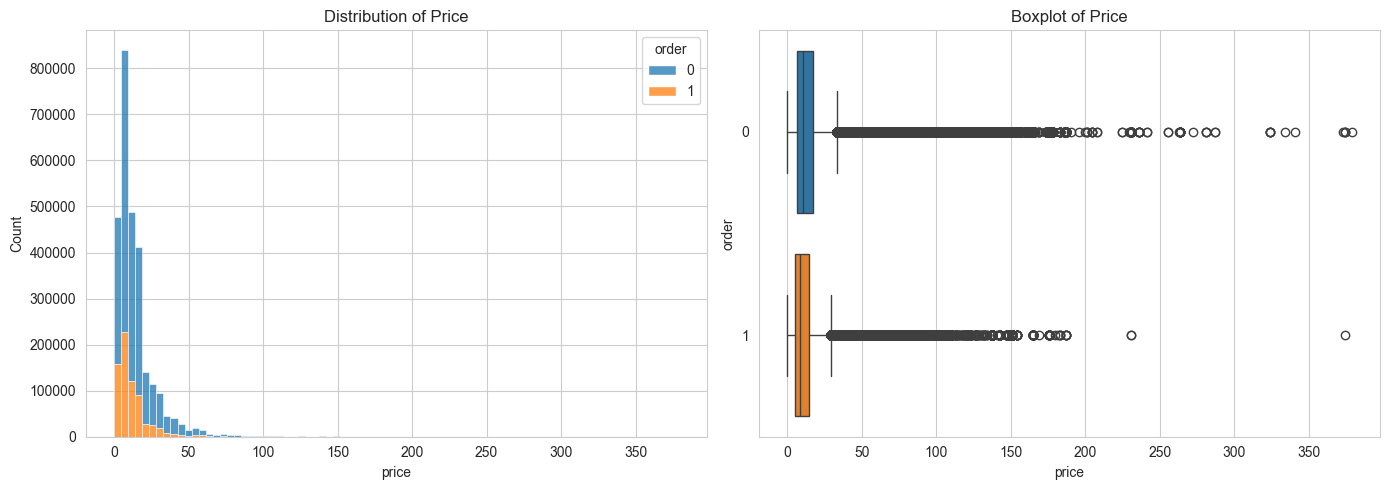

In [183]:
# Numbers
rrp_counts = df['price'].value_counts()
rrp_percentages = (df['price'].value_counts(normalize=True) * 100).round(2)
rrp_order_ct = pd.crosstab(df['price'], df['order'])
rrp_order_ct_pct = (pd.crosstab(df['price'], df['order'], normalize='index') * 100).round(2)
rrp_EDA_df = pd.DataFrame({
    'total_count': rrp_counts,
    'total_percentage': rrp_percentages,
    'order_0_count': rrp_order_ct[0],
    'order_1_count': rrp_order_ct[1],
    'order_0_percentage': rrp_order_ct_pct[0],
    'order_1_percentage': rrp_order_ct_pct[1]
})
print(rrp_EDA_df)
rrp_EDA_df.to_csv('../data/processed/rrp_EDA.csv', index=True)
print(df['rrp'].describe().apply('{0:.2f}'.format))

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df, x='price', hue='order', bins=80, multiple='stack', palette='tab10', ax=axes[0])
axes[0].set_title("Distribution of Price")
sns.boxplot(data=df, x='price', y='order', hue='order', palette='tab10', orient='h', ax=axes[1], legend=False)
axes[1].set_title("Boxplot of Price")
plt.tight_layout()
plt.savefig('../reports/figures/rrp_EDA.png')
plt.show()

#### ***Competitor Price***

        total_count  total_percentage  order_0_count  order_1_count  \
price                                                                 
0.02              2               0.0              2              0   
0.03              8               0.0              7              1   
0.04              4               0.0              4              0   
0.06              1               0.0              1              0   
0.07             66               0.0             33             33   
...             ...               ...            ...            ...   
334.01            1               0.0              1              0   
340.64            1               0.0              1              0   
372.72            1               0.0              1              0   
374.59            4               0.0              3              1   
378.84            1               0.0              1              0   

        order_0_percentage  order_1_percentage  
price                      

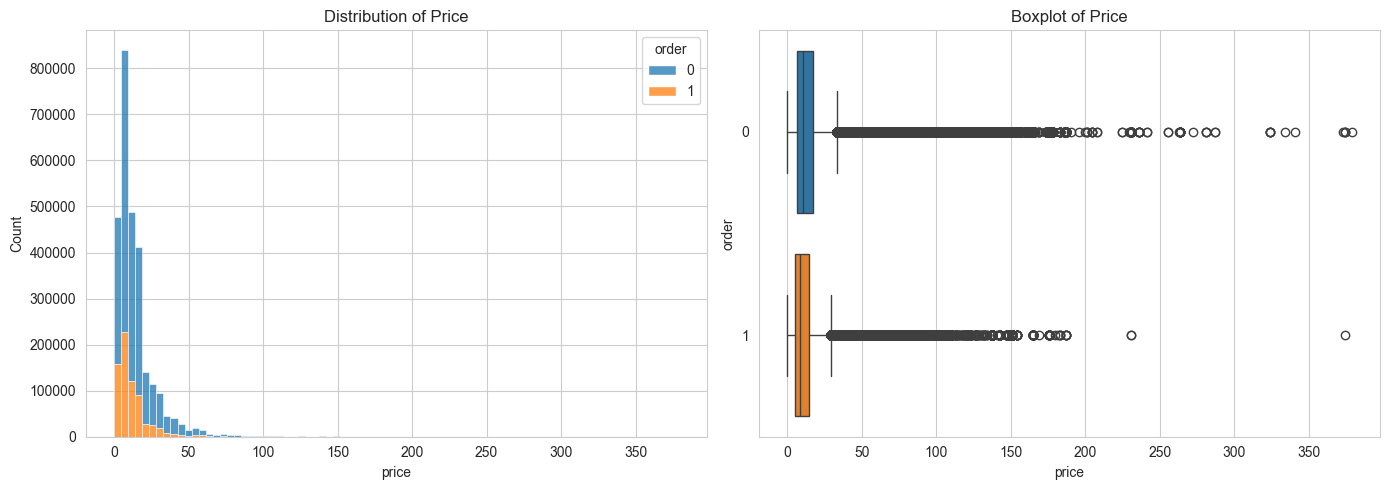

In [184]:
# Numbers
competitorPrice_counts = df['price'].value_counts()
competitorPrice_percentages = (df['price'].value_counts(normalize=True) * 100).round(2)
competitorPrice_order_ct = pd.crosstab(df['price'], df['order'])
competitorPrice_order_ct_pct = (pd.crosstab(df['price'], df['order'], normalize='index') * 100).round(2)
competitorPrice_EDA_df = pd.DataFrame({
    'total_count': competitorPrice_counts,
    'total_percentage': competitorPrice_percentages,
    'order_0_count': competitorPrice_order_ct[0],
    'order_1_count': competitorPrice_order_ct[1],
    'order_0_percentage': competitorPrice_order_ct_pct[0],
    'order_1_percentage': competitorPrice_order_ct_pct[1]
})
print(competitorPrice_EDA_df)
competitorPrice_EDA_df.to_csv('../data/processed/competitorPrice_EDA.csv', index=True)
print(df['competitorPrice'].describe().apply('{0:.2f}'.format))

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df, x='price', hue='order', bins=80, multiple='stack', palette='tab10', ax=axes[0])
axes[0].set_title("Distribution of Price")
sns.boxplot(data=df, x='price', y='order', hue='order', palette='tab10', orient='h', ax=axes[1], legend=False)
axes[1].set_title("Boxplot of Price")
plt.tight_layout()
plt.savefig('../reports/figures/competitorPrice_EDA.png')
plt.show()

# 4 Data Preparation

## 4.1 Handling Missing Values

Our EDA has identified missing values in category, campaignIndex, pharmForm, and competitorPrice. We need to decide on a strategy for each:
- Imputation: Fill missing values with a statistic like the mean, median, or mode.
- Removal: Remove rows with missing values (use with caution, as it can lead to data loss).
- Model-based imputation: Use a model to predict the missing values.
- Create a new category: For categorical variables, you could treat "missing" as a new category.

In [ ]:
# Analyse missing values to determine how to handle them in the next steps. sort by missing percentage in descending order
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing_values, 'missing_percentage': missing_percentage})
missing_df = missing_df.sort_values(by='missing_percentage', ascending=False)
print(missing_df)

                 missing_count  missing_percentage
campaignIndex          2287968               83.02
pharmForm               194124                7.04
competitorPrice         100687                3.65
category                 87394                3.17
lineID                       0                0.00
availability                 0                0.00
adFlag                       0                0.00
pid                          0                0.00
day                          0                0.00
price                        0                0.00
click                        0                0.00
basket                       0                0.00
order                        0                0.00
group                        0                0.00
manufacturer                 0                0.00
revenue                      0                0.00
content                      0                0.00
genericProduct               0                0.00
unit                         0 

In [ ]:
# Analyse if the absence of a value in each column might be correlated with whether an order is placed or not incl. percentage
missing_order_correlation = {}
for column in df.columns:
    missing_order_correlation[column] = df.groupby(df[column].isnull())['order'].mean().round(4) * 100
missing_order_correlation_df = pd.DataFrame(missing_order_correlation).T
missing_order_correlation_df.columns = ['order_percentage_when_missing', 'order_percentage_when_present']
missing_order_correlation_df = missing_order_correlation_df.sort_values(by='order_percentage_when_missing', ascending=False)
print(missing_order_correlation_df)

                 order_percentage_when_missing  order_percentage_when_present
campaignIndex                            27.45                          25.20
pharmForm                                26.02                          19.79
competitorPrice                          25.94                          16.17
category                                 25.83                          18.06
lineID                                   25.58                            NaN
availability                             25.58                            NaN
adFlag                                   25.58                            NaN
pid                                      25.58                            NaN
day                                      25.58                            NaN
price                                    25.58                            NaN
click                                    25.58                            NaN
basket                                   25.58                  

### campainIndex

With 83.02% of its values missing, the campaignIndex column is mostly empty. This significantly limits its usefulness. Standard imputation methods like using the mean, median, or mode are not suitable here, as filling over 80% of the data with a single value would heavily distort the feature's distribution and likely mislead the model.

The crosstabulation shows a clear difference in ordering behavior depending on whether campaignIndex is missing.
- When campaignIndex has a value: The order rate is approximately 27.45% (128,467 orders / 468,035 total).
- When campaignIndex is missing: The order rate is approximately 25.19% (576,623 orders / 2,287,968 total).

While there is a slight difference, the fact that the column is overwhelmingly empty suggests that its predictive power is likely low. The information it provides is minimal because for the vast majority of the data, the only signal is "the value is missing."

Given the extremely high percentage of missing data, the best course of action is to drop the campaignIndex column entirely.

Reasoning:
1. Low Information Content: A feature that is empty 83% of the time is unlikely to provide significant predictive value to a model.
2. Risk of Noise: Keeping the column, even by creating a "missing" category, could introduce noise and complexity to the model for very little gain.
3. Simplification: Removing the column simplifies the feature set, which can lead to a more robust and interpretable model.

In [ ]:
# Drop the 'campaignIndex' column from the DataFrame
# df.drop(columns=['campaignIndex'], inplace=True)

# Verify that the column has been dropped by checking the remaining columns
# print("Verifying 'campaignIndex' column removal. Remaining columns are:")
# print(df.columns)

### pharmForm

The `pharmForm` column has a missing value rate of 7.04%, which is a moderate but significant portion of the data. Simply dropping these rows could discard valuable information and potentially introduce bias if the missingness is not random.

The provided crosstabulation against the `order` variable is highly revealing:
-   **Order Rate when `pharmForm` is Missing**: 26.02%
-   **Order Rate when `pharmForm` is Present**: 19.79%

This disparity indicates that the missingness in `pharmForm` is **not random**; it is informative. Products with a missing `pharmForm` have a noticeably higher propensity to be ordered. This suggests that the absence of this feature is a predictive signal in itself.

There could be several underlying business reasons for this pattern:
1.  **Product Type**: Certain types of products that sell well might not have a standard pharmaceutical form (e.g., cosmetics, health devices, or bundled items).
2.  **Data Entry Practices**: It's possible that for certain popular or fast-moving items, data entry for this specific field is deprioritized, leading to missing values.
3.  **Customer Perception**: The absence of a specific pharmaceutical form might make a product appear more like a general consumer good rather than a specialized medical item, which could broaden its appeal and increase sales.

**Recommended Strategy: Imputation with a 'Missing' Category**

Given that the missingness is a predictive signal, the best approach is to preserve this information. I recommend imputing the `NaN` values with a distinct string, such as `'Missing'`.

**Justification:**
-   **Preserves Information**: This method explicitly captures the signal that the absence of `pharmForm` provides, allowing the machine learning model to learn the relationship between "missingness" and the higher order rate.
-   **Avoids Data Loss**: It prevents the loss of 7.04% of the rows in your dataset, which would happen if you chose to drop them.
-   **Prevents Distortion**: Unlike mean/median/mode imputation, creating a new category does not distort the distribution of existing `pharmForm` categories. It treats the missing data as a unique group, which, according to the data, it is.

This strategy effectively turns the missing data into a useful feature for the model.

In [ ]:
# Impute missing values in 'pharmForm' with the string 'Missing'
# df['pharmForm'].fillna('Missing', inplace=True)

### competitorPrice

The `competitorPrice` column has a relatively low missing value rate of 3.65%. While this percentage is small, the relationship between its missingness and the `order` rate is too significant to ignore.

The crosstabulation reveals a stark contrast:
-   **Order Rate when `competitorPrice` is Missing**: 25.94%
-   **Order Rate when `competitorPrice` is Present**: 16.17%

This is a substantial difference, indicating that products without a listed competitor price are ordered much more frequently. The missingness is clearly **informative** and not random. Dropping these rows would mean discarding a strong predictive signal.

Several business scenarios could explain this phenomenon:
1.  **Exclusive or Unique Products**: The most likely reason is that these products are exclusive to your store. If there are no direct competitors, there is no competitor price to list. Such exclusive items are often highly sought after, leading to a higher purchase rate.
2.  **Loss-Leader or "Too Low to Show" Pricing**: The product's price might be so competitive that the business has chosen not to display the competitor's price to avoid direct price wars or to comply with pricing agreements. This aggressive pricing would naturally drive more orders.
3.  **New Product Launches**: For newly introduced items, the data collection process for competitor pricing may not have been completed yet. These new products might have high initial sales due to launch promotions or novelty effects.

We considered using a product's own price or rrp to fill the missing competitorPrice values. While this seems intuitive, we decided against it for a crucial reason: it would fundamentally alter the meaning of the feature.
The competitorPrice column represents external market data, whereas our price and rrp are internal strategic values. By using our own price for imputation, we would be erasing the powerful signal that the data is missing, which often indicates an exclusive product with no direct competitor. This could mislead the model by creating an artificial relationship in the data.
Therefore, we concluded that creating a separate binary flag to capture the "missingness" and then using a neutral value like the median for imputation is a more robust approach that preserves the feature's integrity.

Instead, because `competitorPrice` is a numerical feature, simply filling it with a value like -1 or 0 could be misinterpreted by some models as a very low price. A more robust approach is to explicitly capture the "missingness" as a feature and then impute the missing price values in a way that doesn't distort the original distribution.

We choose a two-step strategy:
1.  **Create a Binary Flag**: Create a new column, for example `competitorPrice_is_missing`, that is `1` if the `competitorPrice` was missing and `0` otherwise. This directly feeds the powerful "missingness" signal into the model.
2.  **Impute the Original Column**: After creating the flag, you can impute the missing values in the original `competitorPrice` column. A good choice would be the **median** competitor price. Using the median is generally more robust to outliers than the mean. This step ensures the column remains a valid numerical feature without `NaN` values.

**Justification:**
-   **Captures the Signal**: The binary flag ensures the model can directly learn the strong relationship between the absence of a competitor price and a higher order rate.
-   **Preserves the Feature**: Imputing the original column allows you to still use `competitorPrice` as a numerical feature (e.g., to calculate price differences), without having to deal with `NaN`s.
-   **Robustness**: This two-part strategy is more robust and informative than simply filling the missing values with a placeholder like 0 or -1, which could be misinterpreted by the model.

In [ ]:
# Create a binary flag for missing competitorPrice
# df['competitorPrice_is_missing'] = df['competitorPrice'].isnull().astype(int)

# Calculate the median of the 'competitorPrice' column
# median_competitor_price = df['competitorPrice'].median()

# Impute missing values in 'competitorPrice' with the median
# df['competitorPrice'].fillna(median_competitor_price, inplace=True)

# print(f"Median competitor price used for imputation: {median_competitor_price}")
# df[['competitorPrice', 'competitorPrice_is_missing']].head()

### category

Based on the EDA analysis, the `category` column has a high number of unique values and a long-tail distribution. The code also calculates the percentage of missing values for each column.
As the percentage of missing `category` values is small, we could consider imputing them with the mode (most frequent category). However, given its high cardinality, a better approach is to treat "missing" as a separate category. This can even be a useful predictive signal, as the absence of a category might be correlated with whether an order is placed.

Why this is the best strategy:
1. Preserves Data: 3.17% is a significant amount of data to simply delete. Removing these rows could eliminate valuable information from other columns.
2. Avoids Skewing the Distribution: The category feature has high cardinality (many unique values) and a long-tail distribution. Imputing with the most frequent category (the mode) would artificially inflate its importance and might mislead the model.
3. Potential Predictive Power: The fact that a category is missing might itself be a useful signal for the model. For example, products without a category might have a different ordering behavior. Creating a separate "Missing" or "Unknown" category allows the model to learn this potential relationship.

In [ ]:
# Impute missing values in 'category' with 'Missing'
# df['category'].fillna('Missing', inplace=True)

## 4.2 Feature Engineering

### Unit(s) Bought

To address the project's objective of predicting not only whether a product is purchased but also in what quantity, we needed to engineer a target variable for the quantity. The raw data provides revenue and price for each transaction but does not explicitly state the number of units sold.

We derived the units_bought feature by dividing the revenue by the price. This calculation gives us the exact number of units purchased for each order event. For instances where no order occurred (order == 0), the revenue is zero, which correctly results in zero units bought.

To ensure data integrity and prepare the feature for modeling, we handled potential floating-point inaccuracies by rounding the result to the nearest whole number and converting the data type to an integer. This new units_bought column will serve as the target for our regression model, which aims to predict the quantity of a purchase.

In [ ]:
# We fill any potential NaN values (e.g., from 0/0) with 0 and handle division by zero
df['units_bought'] = (df['revenue'] / df['price']).round().fillna(0)

# Convert the column to an integer data type for cleanliness
df['units_bought'] = df['units_bought'].astype(int)

# Display the first few rows with the new column and its data type
print(df[['price', 'revenue', 'order', 'units_bought']].head())
print("\nData type of 'units_bought':", df['units_bought'].dtype)

# Verify the distribution of units bought for actual orders
print("\nValue counts of units_bought for orders > 0:")
print(df[df['order'] == 1]['units_bought'].value_counts().head())
print(df.head())

   price  revenue  order  units_bought
0  16.89     0.00      0             0
1   8.75     0.00      0             0
2  16.06     0.00      0             0
3   6.55     6.55      1             1
4   4.14     4.14      1             1

Data type of 'units_bought': int64

Value counts of units_bought for orders > 0:
units_bought
1    562284
2     94381
3     24038
4     10235
5      7255
Name: count, dtype: int64
